# Titanic Dataset 기반 Feature Engineering 파이프라인 비교 분석

- 문제 유형: Classification
- 목표 변수: `Survived`
- 비교 항목: 결측치 처리, 인코딩, 스케일링, 파생 변수 생성, Feature Selection
- 사용 모델: Logistic Regression, Random Forest
- 가산점 요소: `Pipeline`, `GridSearchCV`, Feature Importance 시각화


## STEP 01. 데이터 준비

Kaggle Titanic Dataset 형식의 `train.csv`를 사용한다. 로컬 데이터가 없으면 공개 mirror URL에서 다운로드하도록 구성하였다.


In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == 'notebook':
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.append(str(PROJECT_DIR / 'src'))

from pipeline_experiment import *

df = load_data(PROJECT_DIR / 'data' / 'train.csv')
print('데이터 shape:', df.shape)
df.head()

데이터 shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
column_desc = pd.read_csv(PROJECT_DIR / 'results' / 'column_description.csv') if (PROJECT_DIR / 'results' / 'column_description.csv').exists() else None
if column_desc is None:
    make_basic_tables(df)
    column_desc = pd.read_csv(PROJECT_DIR / 'results' / 'column_description.csv')
column_desc

,Column,Description,Type
0,PassengerId,Passenger identifier,Identifier
1,Survived,"Survival status: 0 = No, 1 = Yes",Target
2,Pclass,Ticket class: 1/2/3,Ordinal categorical / numeric
3,Name,Passenger name,Text
4,Sex,Passenger sex,Categorical
5,Age,Passenger age,Numeric
6,SibSp,Number of siblings/spouses aboard,Numeric
7,Parch,Number of parents/children aboard,Numeric
8,Ticket,Ticket number,Text
9,Fare,Passenger fare,Numeric


## STEP 02. 탐색적 데이터 분석(EDA)

필수 분석인 결측치 비율, 이상치, 변수 분포, 상관관계, 타겟 분포를 확인한다.


In [3]:
# 결측치 비율
missing_ratio = df.isna().mean().sort_values(ascending=False) * 100
missing_ratio.to_frame('missing_ratio_percent')

,missing_ratio_percent
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [4]:
# 타겟 분포
survived_counts = df['Survived'].value_counts().sort_index()
survived_counts.to_frame('count')

,count
Survived,
0,549
1,342


In [5]:
# EDA 시각화 생성
make_eda_figures(df)
print('EDA figures saved to:', PROJECT_DIR / 'figures')

EDA figures saved to: /mnt/data/titanic_feature_engineering/figures


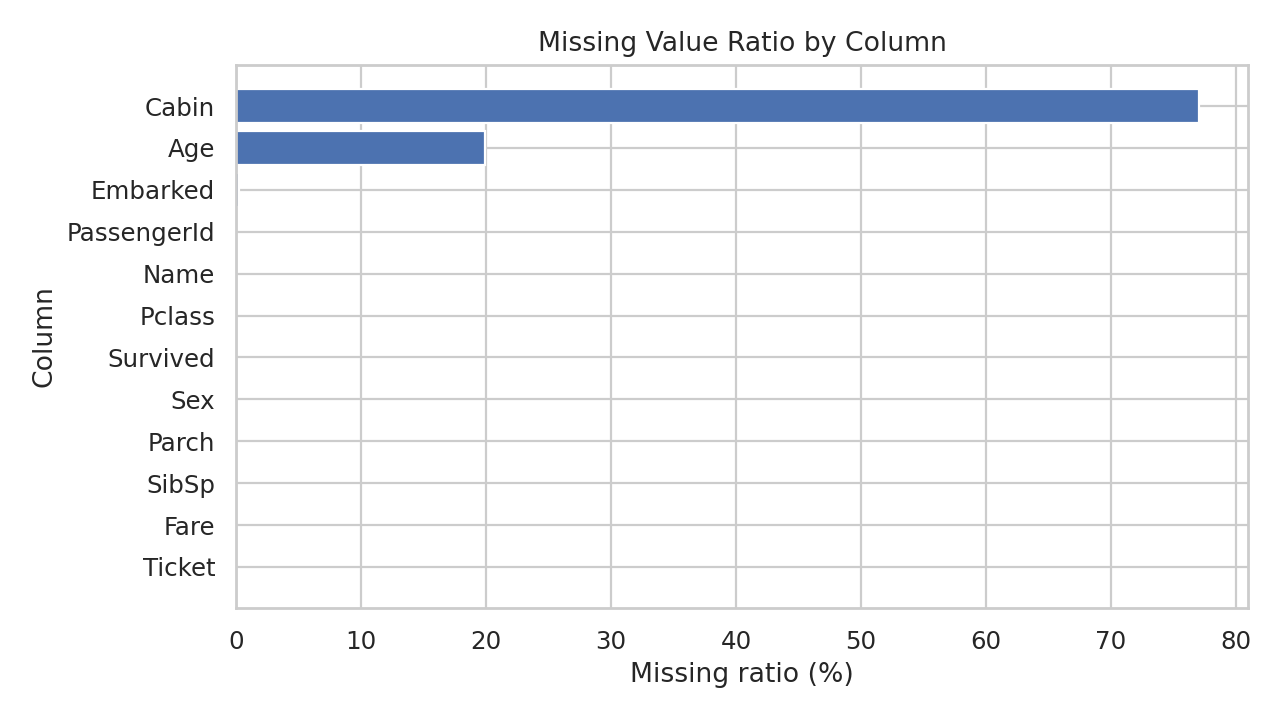

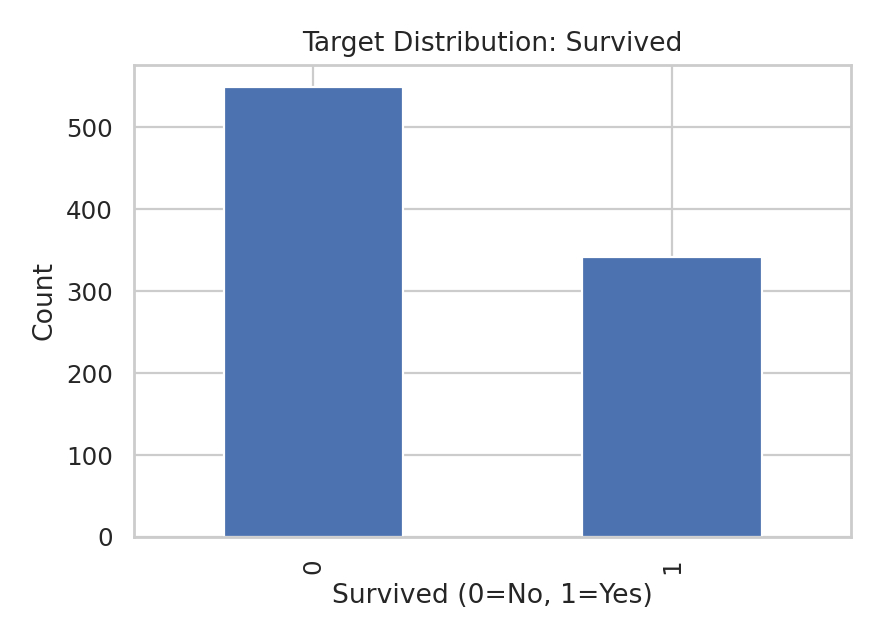

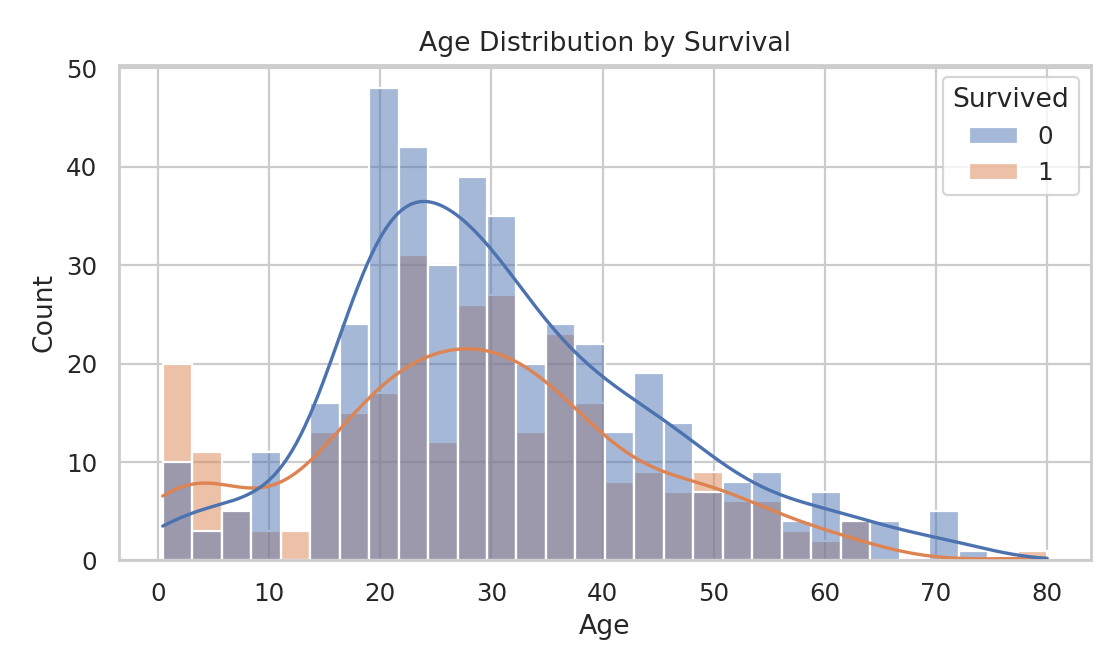

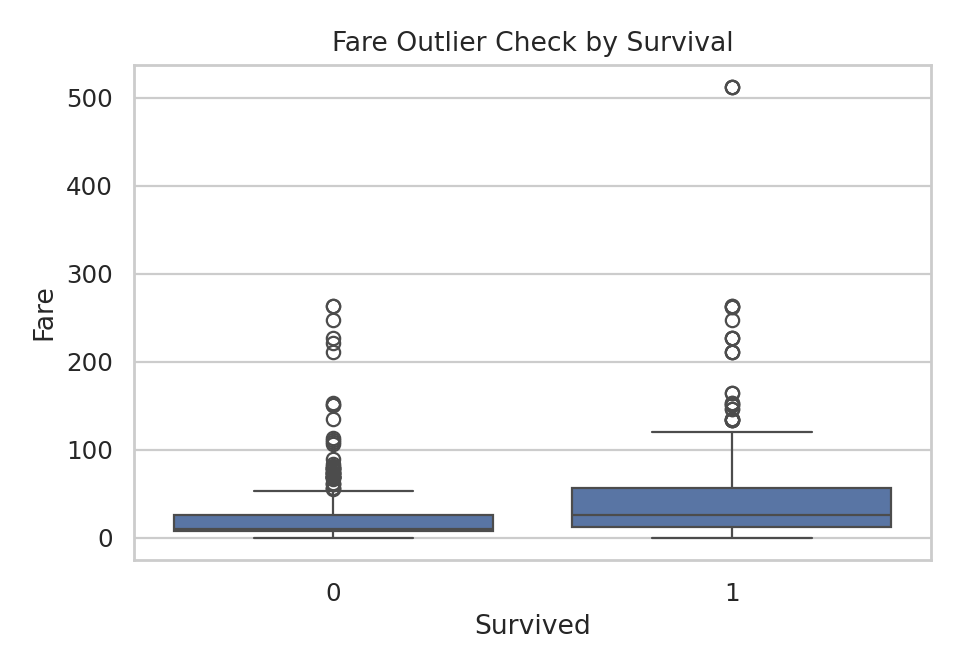

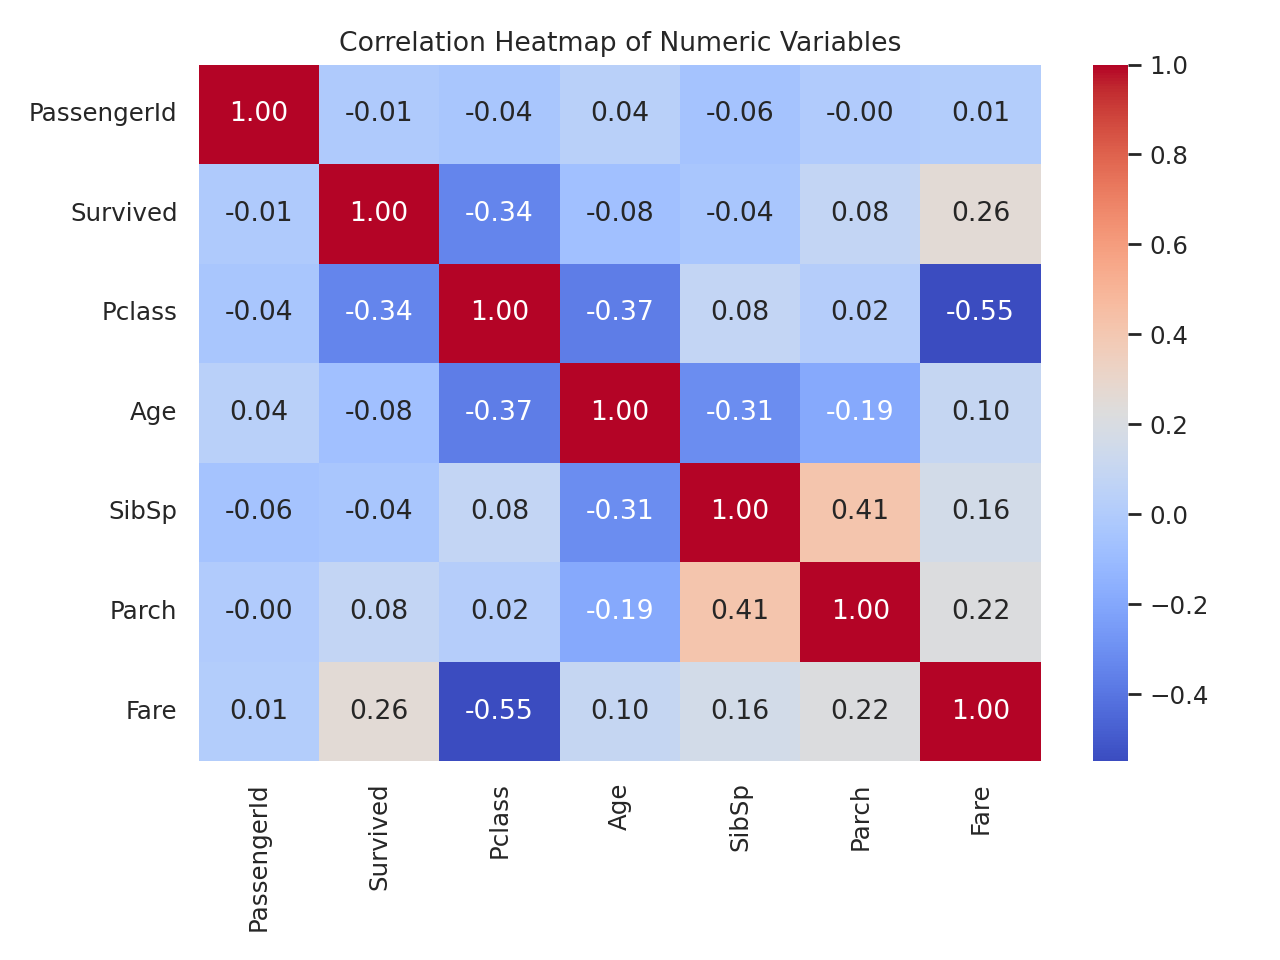

In [6]:
from IPython.display import Image, display
for name in ['eda_missing_ratio.png', 'eda_target_countplot.png', 'eda_age_histogram.png', 'eda_fare_boxplot.png', 'eda_correlation_heatmap.png']:
    display(Image(filename=str(PROJECT_DIR / 'figures' / name)))

## STEP 03. 특성 공학 파이프라인 구현

생존 예측에 도움이 될 수 있는 파생 변수를 생성한다.

생성 변수:
- `FamilySize`: 함께 탑승한 가족 수
- `IsAlone`: 혼자 탑승 여부
- `FarePerPerson`: 1인당 운임
- `Title`: 이름에서 추출한 호칭
- `CabinKnown`, `Deck`: 객실 정보 존재 여부 및 Deck
- `AgeGroup`: 나이 구간


In [7]:
df_fe = add_derived_features(df)
df_fe[['Name', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Title', 'CabinKnown', 'Deck', 'AgeGroup']].head()

,Name,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,Title,CabinKnown,Deck,AgeGroup
0,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,2,0,3.62500,Mr,0,NaN,YoungAdult
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,2,0,35.64165,Mrs,1,C,Adult
2,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,1,1,7.92500,Miss,0,NaN,YoungAdult
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,2,0,26.55000,Mrs,1,C,YoungAdult
4,"Allen, Mr. William Henry",35.0,0,0,8.0500,1,1,8.05000,Mr,0,NaN,YoungAdult


### 실험 조합

| 실험 | 결측치 처리 | 인코딩 | 스케일링 | Feature Selection |
|---|---|---|---|---|
| Base | 없음 | 없음 | 없음 | 없음 |
| Exp-1 | Mean | One-Hot | Standard | X |
| Exp-2 | Median | Label/Ordinal | MinMax | O |
| Exp-3 | Most Frequent | One-Hot | Robust | O |


## STEP 04-05. Feature Selection, 모델 학습 및 평가

`Pipeline` 객체를 사용해 전처리, 변수 선택, 모델 학습을 하나의 흐름으로 묶었다. 평가 지표는 Accuracy, Precision, Recall, F1-score, ROC-AUC를 사용한다.


In [8]:
results, fitted_pipelines, grid_result, importance_df = run_experiments(df)
results[['Experiment', 'Model', 'Missing', 'Encoding', 'Scaling', 'FeatureSelection', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']]

,Experiment,Model,Missing,Encoding,Scaling,FeatureSelection,Accuracy,Precision,Recall,F1,ROC_AUC
2,Exp-1,LogisticRegression,mean,onehot,standard,X,0.843575,0.825397,0.753623,0.787879,0.874045
6,Exp-3,LogisticRegression,most_frequent,onehot,robust,O,0.810056,0.786885,0.695652,0.738462,0.861001
4,Exp-2,LogisticRegression,median,label,minmax,O,0.782123,0.734375,0.681159,0.706767,0.838142
5,Exp-2,RandomForest,median,label,minmax,O,0.782123,0.714286,0.724638,0.719424,0.834058
3,Exp-1,RandomForest,mean,onehot,standard,X,0.798883,0.746269,0.724638,0.735294,0.831621
7,Exp-3,RandomForest,most_frequent,onehot,robust,O,0.815642,0.764706,0.753623,0.759124,0.830303
0,Base,LogisticRegression,none,none,none,X,0.648045,0.562500,0.391304,0.461538,0.673847
1,Base,RandomForest,none,none,none,X,0.592179,0.471429,0.478261,0.474820,0.645191


In [9]:
# Feature Selection 적용 전/후 비교: Exp-1과 Exp-3 비교
fs_compare = pd.read_csv(PROJECT_DIR / 'results' / 'feature_selection_compare.csv')
fs_compare[['Experiment', 'Model', 'FeatureSelection', 'Accuracy', 'F1', 'ROC_AUC']]

,Experiment,Model,FeatureSelection,Accuracy,F1,ROC_AUC
0,Exp-1,LogisticRegression,X,0.843575,0.787879,0.874045
1,Exp-3,LogisticRegression,O,0.810056,0.738462,0.861001
2,Exp-1,RandomForest,X,0.798883,0.735294,0.831621
3,Exp-3,RandomForest,O,0.815642,0.759124,0.830303


In [10]:
# Random Forest Feature Importance 상위 변수
importance_df.head(15)

,feature,importance
1,Age,0.144295
7,FarePerPerson,0.131336
4,Fare,0.127516
16,Title_Mr,0.090710
10,Sex_male,0.088284
9,Sex_female,0.081954
0,Pclass,0.047085
5,FamilySize,0.035697
8,CabinKnown,0.029425
2,SibSp,0.025271


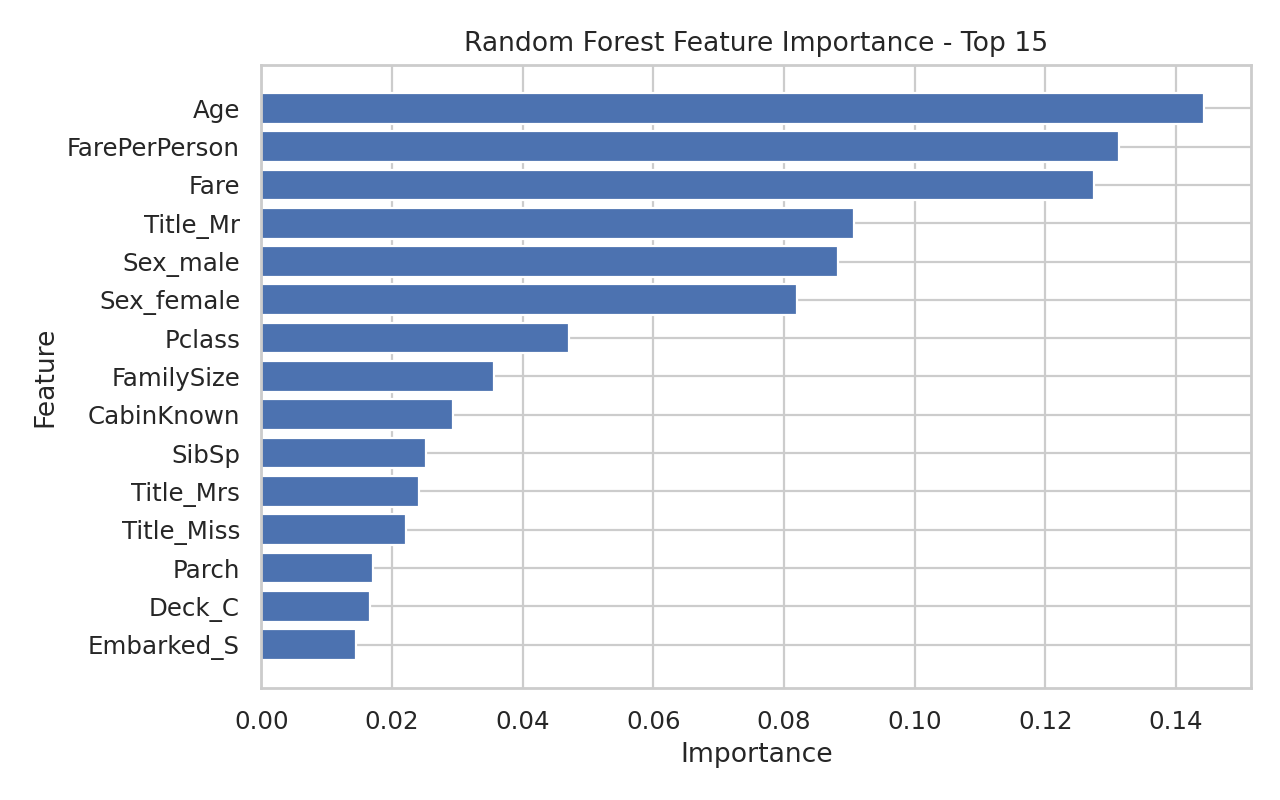

In [11]:
display(Image(filename=str(PROJECT_DIR / 'figures' / 'feature_importance_top15.png')))

## GridSearchCV 추가 실험

가산점 항목을 위해 Exp-3 + RandomForest 조합에 대해 GridSearchCV를 적용하였다.


In [12]:
grid_result

,Experiment,Model,BestParams,CV_Best_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Exp-3 + GridSearchCV,RandomForest,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.873696,0.821229,0.784615,0.73913,0.761194,0.848617


## 최종 해석

- Base 모델은 수치형 기본 변수만 사용했기 때문에 성능이 낮게 나타났다.
- Exp-1은 Mean Imputation, One-Hot Encoding, StandardScaler, 파생 변수를 함께 사용하여 Logistic Regression에서 가장 높은 ROC-AUC를 보였다.
- Label/Ordinal Encoding은 범주형 변수에 순서 관계를 부여할 수 있어 One-Hot 대비 성능이 제한될 수 있다.
- Feature Selection은 변수를 줄여 모델을 단순화하는 장점이 있으나, 본 실험에서는 전체 변수를 사용하는 Exp-1 Logistic Regression이 가장 안정적이었다.
- Random Forest Feature Importance 기준으로 Age, FarePerPerson, Fare, Title, Sex 관련 변수가 생존 예측에 중요한 변수로 나타났다.
